In [1]:
import numpy as np

window_len = 400
fs = 200

chb_14_label_0 = np.load('Data_\chb14\label_0.npy')  # Normal
chb_14_label_1 = np.load('Data_\chb14\label_1.npy')  # Seizure

chb_01_label_0 = np.load('Data_\chb01\label_0.npy')  # Normal
chb_01_label_1 = np.load('Data_\chb01\label_1.npy')  # Seizure

In [2]:
print(f"chb_14_label_0_shape: {chb_14_label_0.shape}")
print(f"chb_14_label_1_shape: {chb_14_label_1.shape}\n")
print(f"Data ratio: {chb_14_label_0.shape[1]/chb_14_label_1.shape[1]}:1")


chb_14_label_0_shape: (16, 240000)
chb_14_label_1_shape: (16, 33800)

Data ratio: 7.100591715976331:1


In [3]:
def sliding_window(data, window_size=400, stride=50):
    channels, total_time = data.shape
    num_windows = (total_time - window_size) // stride + 1
    windows = np.array([
        data[:, i * stride : i * stride + window_size]
        for i in range(num_windows)
    ])
    return windows

In [4]:
chb_14_windows_0 = sliding_window(chb_14_label_0, window_size=400, stride=50)
chb_14_windows_1 = sliding_window(chb_14_label_1, window_size=400, stride=50)

print(f"chb_14_label_0_Number : {chb_14_windows_0.shape}")
print(f"chb_14_label_1_Number : {chb_14_windows_1.shape}\n")

chb_14_label_0_Number : (4793, 16, 400)
chb_14_label_1_Number : (669, 16, 400)



In [5]:
chb_01_windows_0 = sliding_window(chb_01_label_0, window_size=400, stride=50)
chb_01_windows_1 = sliding_window(chb_01_label_1, window_size=400, stride=50)

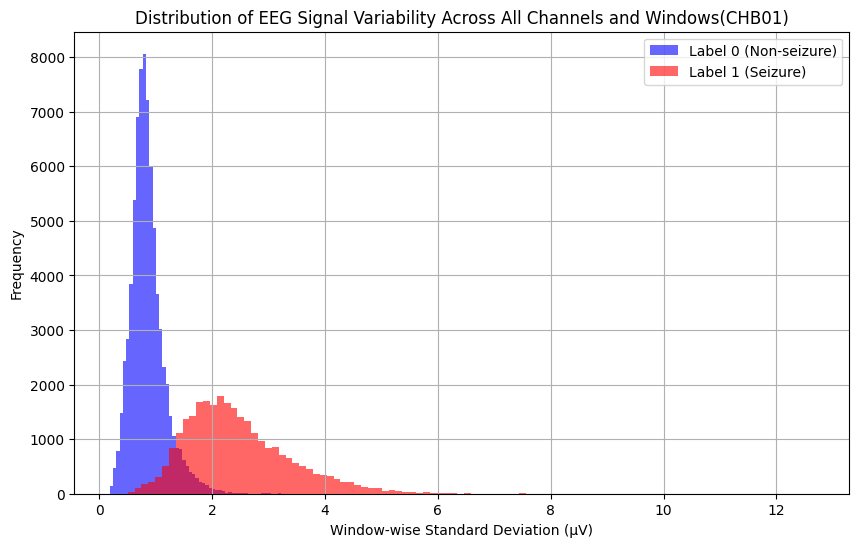

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

def extract_window_features(data, win_len=400, stride=50):
    n_channels, total_len = data.shape
    n_windows = (total_len - win_len) // stride + 1
    
    features = {
        'mean': [],
        'std': [],
        'kurtosis': []
    }
    
    for i in range(n_windows):
        start = i * stride
        end = start + win_len
        window = data[:, start:end]
        
        features['mean'].append(np.mean(window, axis=1))
        features['std'].append(np.std(window, axis=1))
        features['kurtosis'].append(kurtosis(window, axis=1))
    
    return {k: np.array(v) for k, v in features.items()}

# get 
feat_0 = extract_window_features(chb_01_label_0)
feat_1 = extract_window_features(chb_01_label_1)

# plot Std distribution
plt.figure(figsize=(10, 6))
plt.hist(feat_0['std'].flatten(), bins=100, alpha=0.6, label='Label 0 (Non-seizure)', color='blue')
plt.hist(feat_1['std'].flatten(), bins=100, alpha=0.6, label='Label 1 (Seizure)', color='red')
plt.xlabel('Window-wise Standard Deviation (μV)')
plt.ylabel('Frequency')
name = "CHB01"
plt.title(f'Distribution of EEG Signal Variability Across All Channels and Windows({name})')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import matplotlib.pyplot as plt

def plot_16_channels(data, fs=200, title=""):
    n_channels, n_samples = data.shape
    assert n_channels == 16, "Data must have exactly 16 channels."
    
    time = np.arange(n_samples) / fs  # Convert samples to seconds
    
    fig, axes = plt.subplots(16, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(title, fontsize=14)
    
    for i in range(16):
        axes[i].plot(time, data[i], color='black', linewidth=0.5)
        axes[i].set_ylabel(f'Ch {i+1}', fontsize=8)
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].set_yticks([])  # Hide y-ticks for clarity
    
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Make room for suptitle
    plt.show()

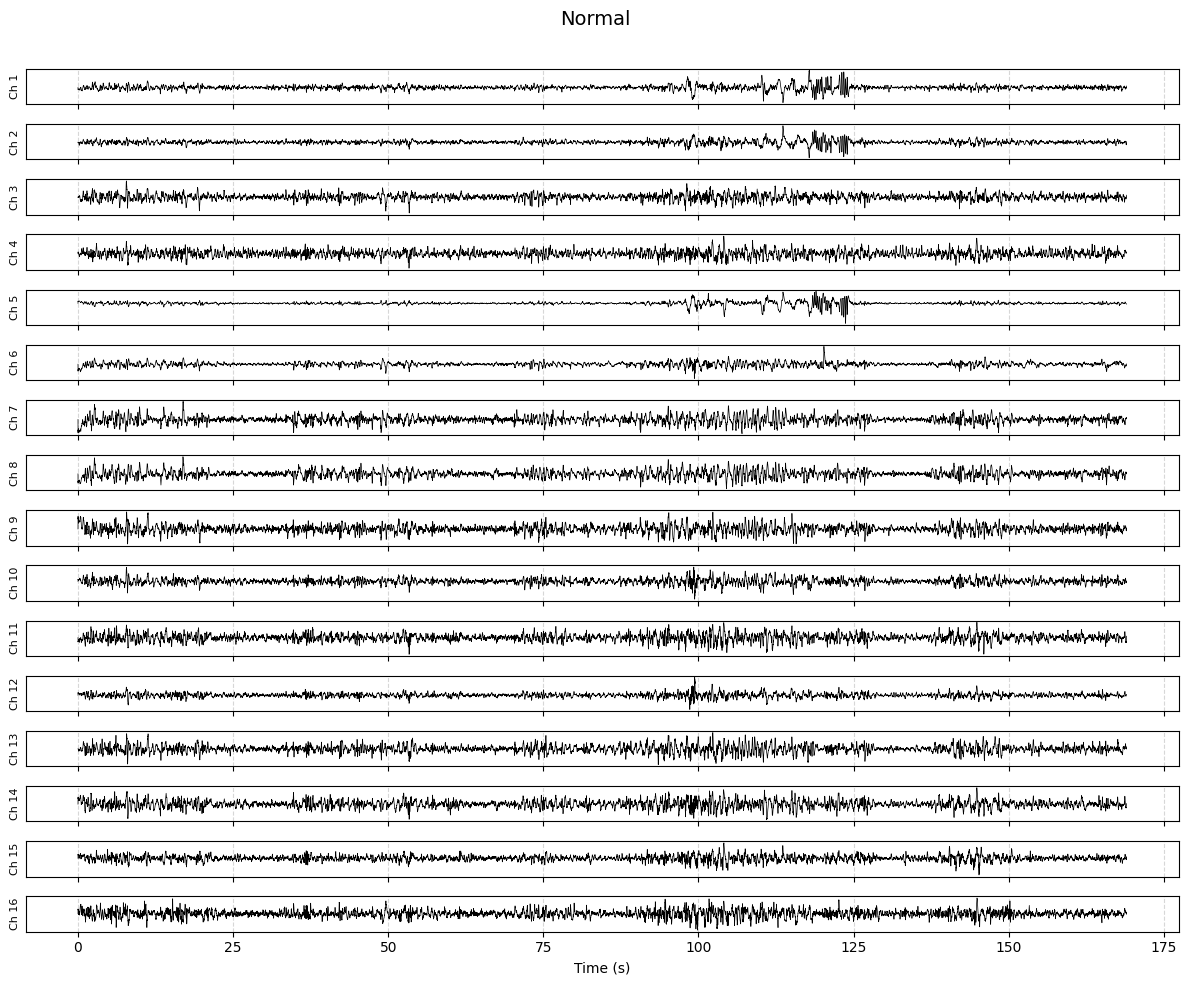

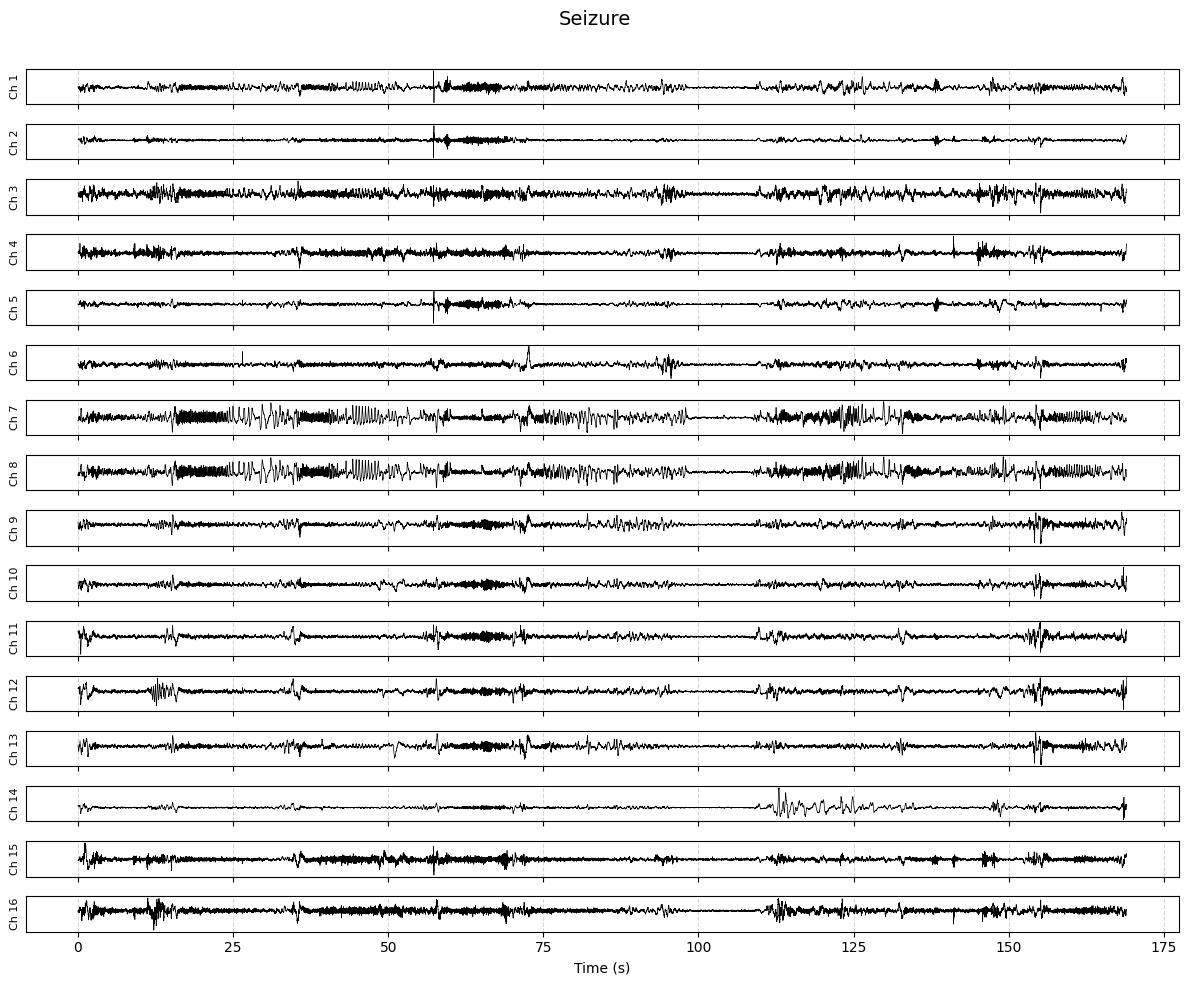

In [8]:
plot_16_channels(chb_14_label_0[:,0:chb_14_label_1.shape[1]],title="Normal")
plot_16_channels(chb_14_label_1,title="Seizure")

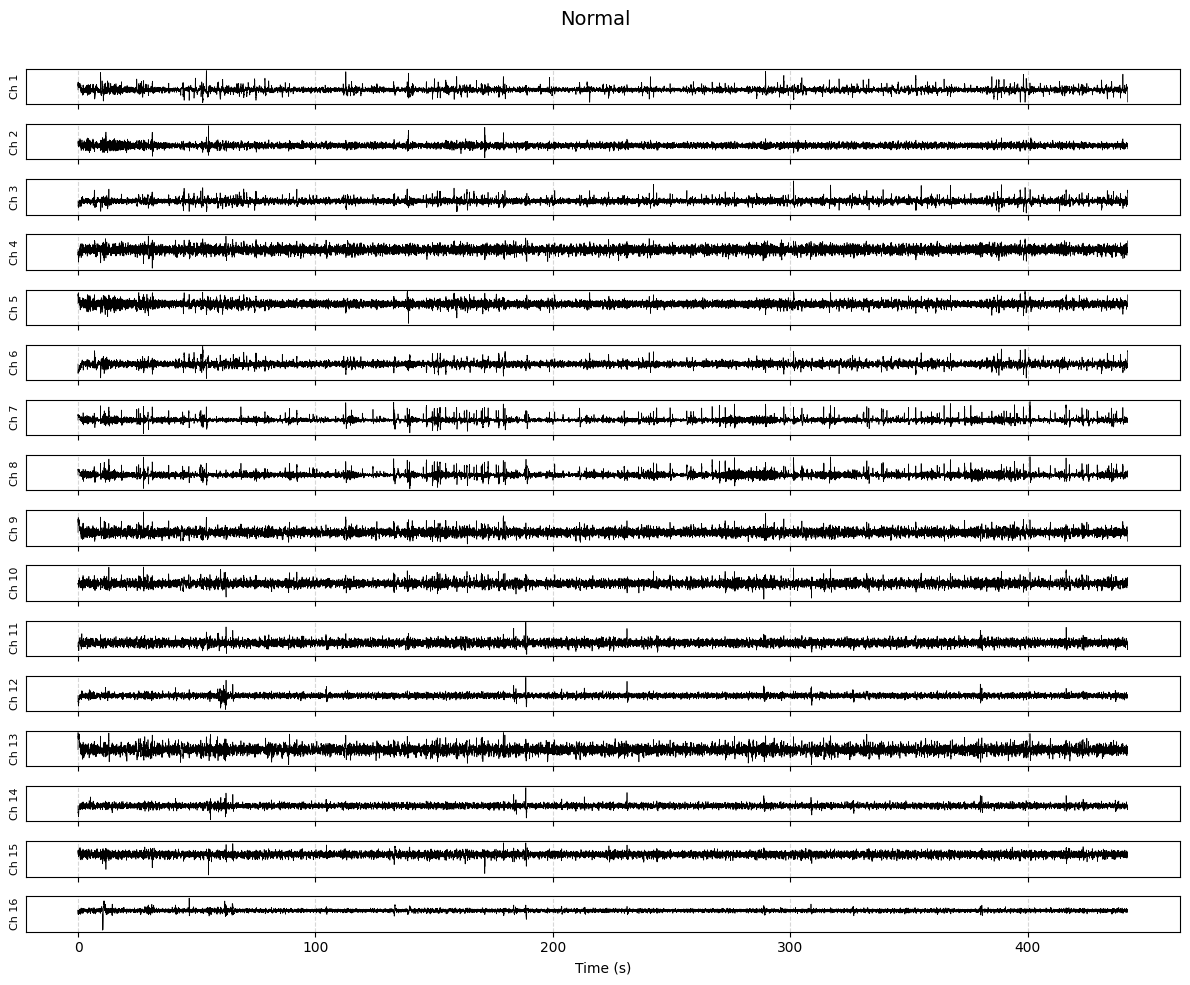

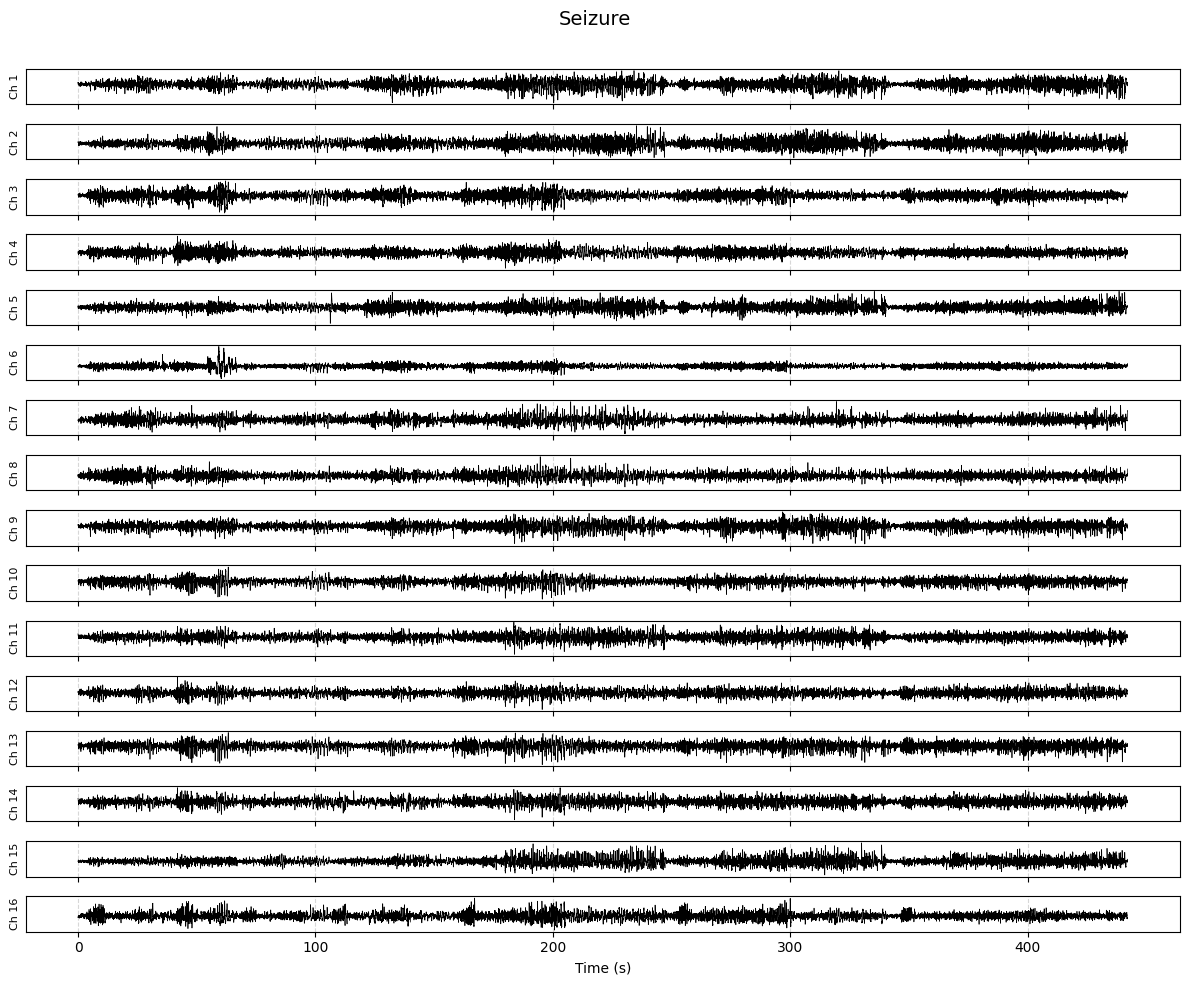

In [9]:
plot_16_channels(chb_01_label_0[:,0:chb_01_label_1.shape[1]],title="Normal")
plot_16_channels(chb_01_label_1,title="Seizure")

f:\Anaconda3\envs\CHB_MIT\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "f:\Anaconda3\envs\CHB_MIT\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "f:\Anaconda3\envs\CHB_MIT\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "f:\Anaconda3\envs\CHB_MIT\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "f:\Anaconda3\envs\CHB_MIT\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


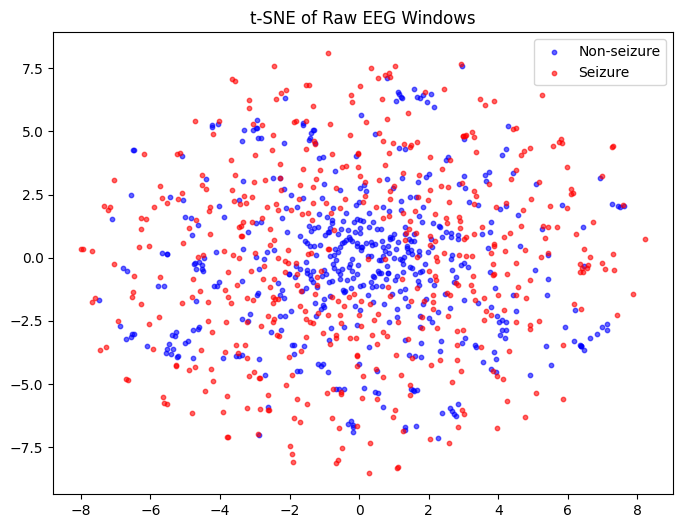

In [10]:
from sklearn.manifold import TSNE

# sample-random  
np.random.seed(42) 
n_sub = 500
sub0 = chb_01_windows_0[np.random.choice(chb_01_windows_0.shape[0], n_sub, replace=False)].reshape(n_sub, -1)
sub1 = chb_01_windows_1[np.random.choice(chb_01_windows_1.shape[0], n_sub, replace=False)].reshape(n_sub, -1)

X = np.vstack([sub0, sub1])
y = np.hstack([np.zeros(n_sub), np.ones(n_sub)])

# t-SNE dim-reduct
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X2d = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X2d[y==0, 0], X2d[y==0, 1], c='blue', s=10, alpha=0.6, label='Non-seizure')
plt.scatter(X2d[y==1, 0], X2d[y==1, 1], c='red', s=10, alpha=0.6, label='Seizure')
plt.title('t-SNE of Raw EEG Windows')
plt.legend()
plt.show()

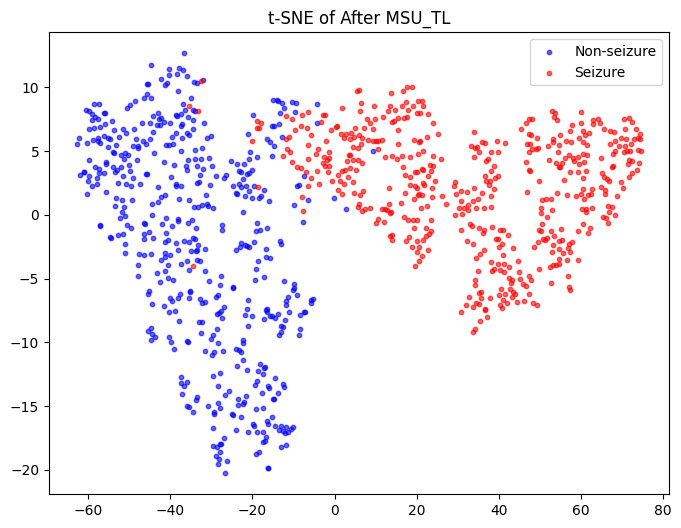

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from model_.unit_ import MSU_

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
pre_model = MSU_()
pre_model.load_state_dict(torch.load('best_pretrain.pth', weights_only=True))
pre_model.to(device)
pre_model.eval()
for param in pre_model.parameters():
    param.requires_grad = False

# Feature extraction function (batched)
def extract_features(windows, model, device, batch_size=64):
    model.eval()
    all_feats = []
    with torch.no_grad():
        for i in range(0, len(windows), batch_size):
            batch = torch.from_numpy(windows[i:i+batch_size]).float().to(device)
            output = model(batch)
            feat = output[0][-1]  # shape: (B, D)
            all_feats.append(feat.cpu().numpy())
    return np.concatenate(all_feats, axis=0)

np.random.seed(42)  
n_sub = 500

# sample-random
idx0 = np.random.choice(chb_01_windows_0.shape[0], size=min(n_sub, chb_01_windows_0.shape[0]), replace=False)
idx1 = np.random.choice(chb_01_windows_1.shape[0], size=min(n_sub, chb_01_windows_1.shape[0]), replace=False)
sampled_0 = chb_01_windows_0[idx0]
sampled_1 = chb_01_windows_1[idx1]

# get feature
feat_0 = extract_features(sampled_0, pre_model, device)
feat_1 = extract_features(sampled_1, pre_model, device)

# combine
X = np.vstack([feat_0, feat_1])
y = np.hstack([np.zeros(len(feat_0)), np.ones(len(feat_1))])

# t-SNE dim-reduct
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X2d = tsne.fit_transform(X)

# plot Scatter point
plt.figure(figsize=(8, 6))
plt.scatter(X2d[y == 0, 0], X2d[y == 0, 1], c='blue', s=10, alpha=0.6, label='Non-seizure')
plt.scatter(X2d[y == 1, 0], X2d[y == 1, 1], c='red', s=10, alpha=0.6, label='Seizure')
plt.title('t-SNE of After MSU_TL')  
plt.legend()
plt.show()